In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import atan2, degrees, radians, cos, sin, sqrt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from matplotlib.colors import ListedColormap

In [2]:
data = pd.read_csv('../exports/v2flo.csv')
data

,#,id,milesId,time,time.1,location,location.1
0,1,3003,26815,2025-03-07 19:33:10,2025-03-07 19:53:27,"(13.3195782,52.4945946)","(13.2633362,52.45228)"
1,2,2053,10431,2025-03-07 19:01:01,2025-03-07 19:23:47,"(13.2859755,52.55147)","(13.3704653,52.55936)"
2,3,2259,15244,2025-03-07 19:06:42,2025-03-07 19:23:48,"(13.46344,52.51451)","(13.46736,52.50795)"
3,4,1816,15723,2025-03-07 18:51:57,2025-03-07 19:23:51,"(13.33404,52.5076256)","(13.4013672,52.54689)"
4,5,1781,25414,2025-03-07 18:50:30,2025-03-07 19:23:54,"(13.4114628,52.5603256)","(13.3309135,52.52134)"
...,...,...,...,...,...,...,...
89338,89339,134,18303,2025-03-07 18:05:09,2025-03-07 18:37:10,"(13.3171062,52.5108871)","(13.3930788,52.5392075)"
89339,89340,617,6658,2025-03-07 18:16:17,2025-03-07 18:37:12,"(13.4331951,52.4891129)","(13.4585161,52.5108)"
89340,89341,1050,26927,2025-03-07 18:28:29,2025-03-07 18:37:25,"(13.4176693,52.53797)","(13.405237,52.532822)"
89341,89342,456,22951,2025-03-07 18:12:31,2025-03-07 18:37:39,"(13.1535482,52.5306473)","(13.201793,52.53426)"


In [3]:
# Function to extract lat/lon from location strings
def extract_coordinates(location_str):
    # Remove parentheses and split by comma
    coords = location_str.strip('()').split(',')
    lon = float(coords[0].strip())
    lat = float(coords[1].strip())
    return lat, lon

# Calculate direction in degrees (0-360, where 0 is North)
def calculate_direction(start_lat, start_lon, end_lat, end_lon):
    # Calculate the difference in coordinates
    d_lon = end_lon - start_lon
    d_lat = end_lat - start_lat
    
    # Calculate the angle in radians
    angle = atan2(d_lon, d_lat)
    
    # Convert to degrees and normalize to 0-360 range
    angle_deg = (degrees(angle) + 360) % 360
    
    return angle_deg

# Calculate distance between two points in meters
def haversine_distance(lat1, lon1, lat2, lon2):
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    r = 6371000  # Earth radius in meters
    
    return r * c

In [6]:
data['start_lat'], data['start_lon'] = zip(*data['location'].apply(extract_coordinates))
data['end_lat'], data['end_lon'] = zip(*data['location.1'].apply(extract_coordinates))

data['direction'] = data.apply(lambda row: calculate_direction(
    row['start_lat'], row['start_lon'], row['end_lat'], row['end_lon']), axis=1)

data['distance'] = data.apply(lambda row: haversine_distance(
    row['start_lat'], row['start_lon'], row['end_lat'], row['end_lon']), axis=1)

# only in 13<lng<14 and 52<lat<53
filtered = data[(data['start_lon'] > 13) & (data['start_lon'] < 14) & (data['start_lat'] > 52) & (data['start_lat'] < 53)]

filtered

,#,id,milesId,time,time.1,location,location.1,start_lat,start_lon,end_lat,end_lon,direction,distance
0,1,3003,26815,2025-03-07 19:33:10,2025-03-07 19:53:27,"(13.3195782,52.4945946)","(13.2633362,52.45228)",52.494595,13.319578,52.452280,13.263336,233.043421,6053.927680
1,2,2053,10431,2025-03-07 19:01:01,2025-03-07 19:23:47,"(13.2859755,52.55147)","(13.3704653,52.55936)",52.551470,13.285975,52.559360,13.370465,84.664960,5778.985980
2,3,2259,15244,2025-03-07 19:06:42,2025-03-07 19:23:48,"(13.46344,52.51451)","(13.46736,52.50795)",52.514510,13.463440,52.507950,13.467360,149.139108,776.179875
3,4,1816,15723,2025-03-07 18:51:57,2025-03-07 19:23:51,"(13.33404,52.5076256)","(13.4013672,52.54689)",52.507626,13.334040,52.546890,13.401367,59.749786,6309.250137
4,5,1781,25414,2025-03-07 18:50:30,2025-03-07 19:23:54,"(13.4114628,52.5603256)","(13.3309135,52.52134)",52.560326,13.411463,52.521340,13.330913,244.173168,6961.789962
...,...,...,...,...,...,...,...,...,...,...,...,...,...
89338,89339,134,18303,2025-03-07 18:05:09,2025-03-07 18:37:10,"(13.3171062,52.5108871)","(13.3930788,52.5392075)",52.510887,13.317106,52.539208,13.393079,69.555992,6027.744663
89339,89340,617,6658,2025-03-07 18:16:17,2025-03-07 18:37:12,"(13.4331951,52.4891129)","(13.4585161,52.5108)",52.489113,13.433195,52.510800,13.458516,49.420384,2958.570769
89340,89341,1050,26927,2025-03-07 18:28:29,2025-03-07 18:37:25,"(13.4176693,52.53797)","(13.405237,52.532822)",52.537970,13.417669,52.532822,13.405237,247.506402,1017.229542
89341,89342,456,22951,2025-03-07 18:12:31,2025-03-07 18:37:39,"(13.1535482,52.5306473)","(13.201793,52.53426)",52.530647,13.153548,52.534260,13.201793,85.717531,3287.968626


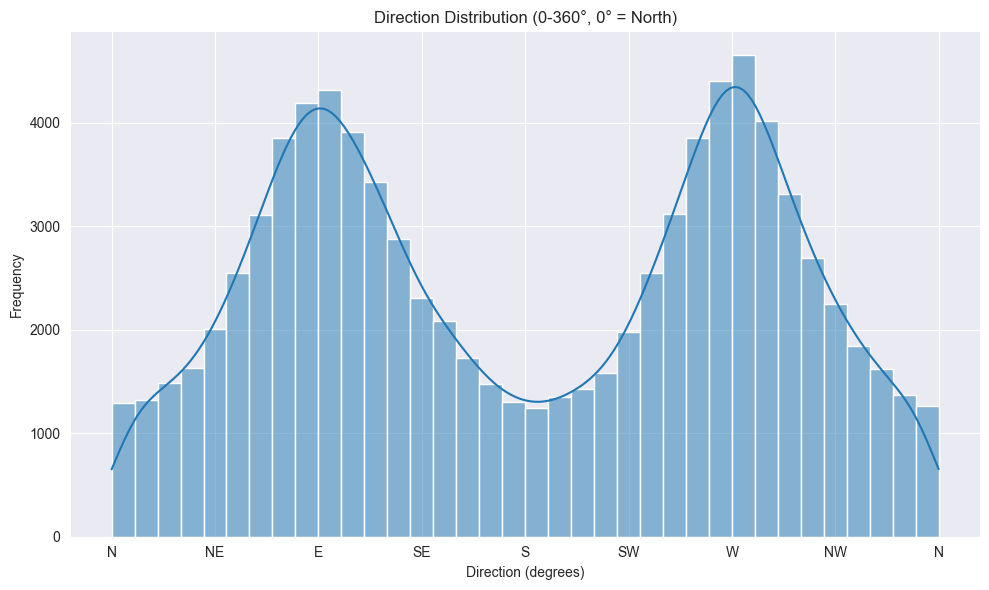

In [22]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=filtered, x='direction', bins=36, kde=True)
ax.set_title('Direction Distribution (0-360°, 0° = North)')
ax.set_xlabel('Direction (degrees)')
ax.set_ylabel('Frequency')
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'N'])
plt.tight_layout()
plt.show()

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

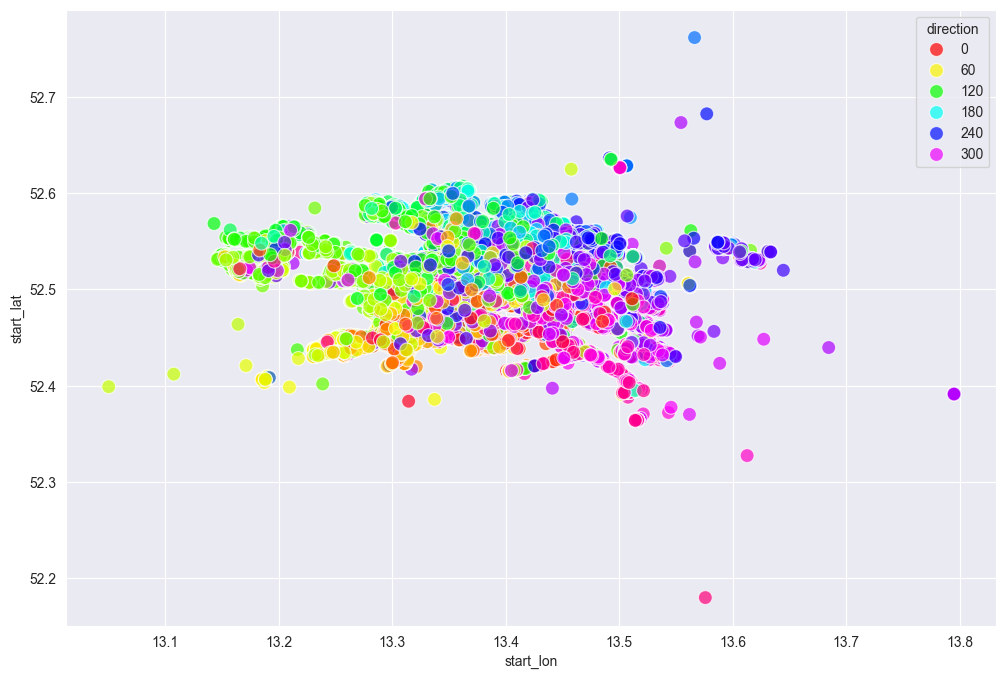

In [23]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=filtered,
    x='start_lon',
    y='start_lat',
    hue='direction',
    palette='hsv',  # Use HSV colormap for circular data
    hue_norm=(0, 360),
    s=100,  # Point size
    alpha=0.7
)

# Add a colorbar
norm = plt.Normalize(0, 360)
sm = plt.cm.ScalarMappable(cmap='hsv', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Direction (degrees)')

# Add directional markers to show the direction from each point
arrow_scale = 0.05  # Scale factor for arrows
for _, row in data.iterrows():
    direction_rad = np.radians(row['direction'])
    dx = arrow_scale * np.sin(direction_rad)
    dy = arrow_scale * np.cos(direction_rad)
    plt.arrow(row['start_lon'], row['start_lat'], dx, dy, 
              head_width=0.02, head_length=0.03, fc='black', ec='black')

plt.title('Starting Locations with Direction Indicators')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

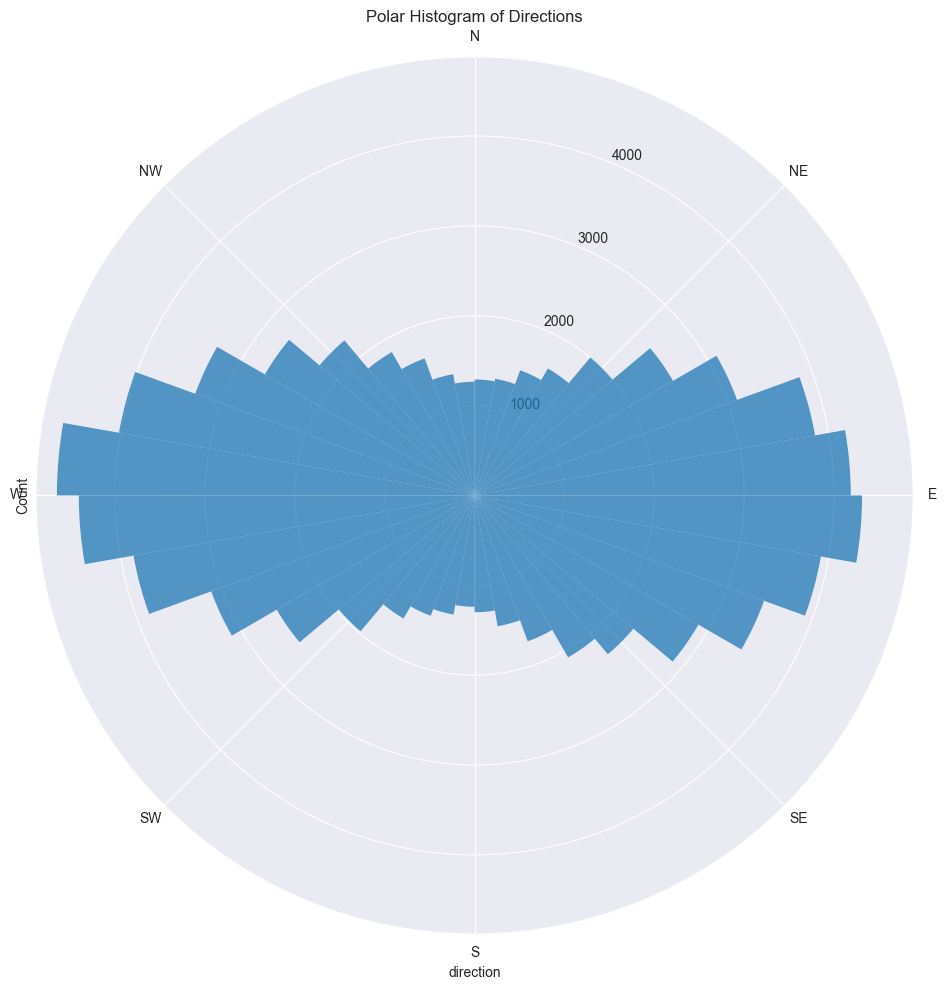

In [24]:
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')
ax.set_theta_zero_location('N')  # 0 degrees at the top (North)
ax.set_theta_direction(-1)  # Clockwise

# Convert to radians for polar plot
directions_rad = np.radians(data['direction'])
sns.histplot(directions_rad, bins=36, ax=ax)

ax.set_title('Polar Histogram of Directions')
ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
plt.tight_layout()
plt.show()

In [12]:
LON_METERS = 68000  # meters per degree longitude at ~52.5° latitude
LAT_METERS = 111000  # meters per degree latitude

# Define the grid size (500m x 500m)
GRID_SIZE = 1000  # meters

# Calculate grid indices for each point
filtered['grid_lon'] = ((filtered['start_lon'] - 13) * LON_METERS / GRID_SIZE).astype(int)
filtered['grid_lat'] = ((filtered['start_lat'] - 52) * LAT_METERS / GRID_SIZE).astype(int)
filtered['grid_id'] = filtered['grid_lat'].astype(str) + '_' + filtered['grid_lon'].astype(str)

filtered

/var/folders/tc/7w07w7jx5t94vzd3vv914hlh0000gn/T/ipykernel_21897/919823254.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['grid_lon'] = ((filtered['start_lon'] - 13) * LON_METERS / GRID_SIZE).astype(int)
/var/folders/tc/7w07w7jx5t94vzd3vv914hlh0000gn/T/ipykernel_21897/919823254.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['grid_lat'] = ((filtered['start_lat'] - 52) * LAT_METERS / GRID_SIZE).astype(int)
/var/folders/tc/7w07w7jx5t94vzd3vv914hlh0000gn/T/ipykernel_21897/919823254.p

,#,id,milesId,time,time.1,location,location.1,start_lat,start_lon,end_lat,end_lon,direction,distance,grid_lon,grid_lat,grid_id
0,1,3003,26815,2025-03-07 19:33:10,2025-03-07 19:53:27,"(13.3195782,52.4945946)","(13.2633362,52.45228)",52.494595,13.319578,52.452280,13.263336,233.043421,6053.927680,21,54,54_21
1,2,2053,10431,2025-03-07 19:01:01,2025-03-07 19:23:47,"(13.2859755,52.55147)","(13.3704653,52.55936)",52.551470,13.285975,52.559360,13.370465,84.664960,5778.985980,19,61,61_19
2,3,2259,15244,2025-03-07 19:06:42,2025-03-07 19:23:48,"(13.46344,52.51451)","(13.46736,52.50795)",52.514510,13.463440,52.507950,13.467360,149.139108,776.179875,31,57,57_31
3,4,1816,15723,2025-03-07 18:51:57,2025-03-07 19:23:51,"(13.33404,52.5076256)","(13.4013672,52.54689)",52.507626,13.334040,52.546890,13.401367,59.749786,6309.250137,22,56,56_22
4,5,1781,25414,2025-03-07 18:50:30,2025-03-07 19:23:54,"(13.4114628,52.5603256)","(13.3309135,52.52134)",52.560326,13.411463,52.521340,13.330913,244.173168,6961.789962,27,62,62_27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89338,89339,134,18303,2025-03-07 18:05:09,2025-03-07 18:37:10,"(13.3171062,52.5108871)","(13.3930788,52.5392075)",52.510887,13.317106,52.539208,13.393079,69.555992,6027.744663,21,56,56_21
89339,89340,617,6658,2025-03-07 18:16:17,2025-03-07 18:37:12,"(13.4331951,52.4891129)","(13.4585161,52.5108)",52.489113,13.433195,52.510800,13.458516,49.420384,2958.570769,29,54,54_29
89340,89341,1050,26927,2025-03-07 18:28:29,2025-03-07 18:37:25,"(13.4176693,52.53797)","(13.405237,52.532822)",52.537970,13.417669,52.532822,13.405237,247.506402,1017.229542,28,59,59_28
89341,89342,456,22951,2025-03-07 18:12:31,2025-03-07 18:37:39,"(13.1535482,52.5306473)","(13.201793,52.53426)",52.530647,13.153548,52.534260,13.201793,85.717531,3287.968626,10,58,58_10


In [13]:
def circular_mean(angles_deg):
    if len(angles_deg) == 0:
        return np.nan
    
    # Convert to radians
    angles_rad = np.radians(angles_deg)
    
    # Calculate the mean of sin and cos components
    mean_sin = np.mean(np.sin(angles_rad))
    mean_cos = np.mean(np.cos(angles_rad))
    
    # Calculate the circular mean
    mean_direction = np.degrees(np.arctan2(mean_sin, mean_cos))
    
    # Normalize to 0-360
    mean_direction = (mean_direction + 360) % 360
    
    return mean_direction

In [26]:
def directional_coherence(angles_deg):
    if len(angles_deg) <= 1:
        return 1.0  # Perfect coherence for single point
    
    # Convert to radians
    angles_rad = np.radians(angles_deg)
    
    # Calculate the mean of sin and cos components
    mean_sin = np.mean(np.sin(angles_rad))
    mean_cos = np.mean(np.cos(angles_rad))
    
    # Calculate the resultant vector length (measure of coherence)
    r = np.sqrt(mean_sin**2 + mean_cos**2)
    
    return r 

In [28]:
grid_stats = []

for grid_id, group in filtered.groupby('grid_id'):
    if len(group) >= 1:  # Only consider cells with at least one point
        avg_direction = circular_mean(group['direction'])
        avg_distance = group['distance'].mean()
        coherence = directional_coherence(group['direction'])
        grid_lat, grid_lon = grid_id.split('_')
        
        # Calculate the center coordinates of the grid cell
        center_lon = 13 + (int(grid_lon) + 0.5) * GRID_SIZE / LON_METERS
        center_lat = 52 + (int(grid_lat) + 0.5) * GRID_SIZE / LAT_METERS
        
        grid_stats.append({
            'grid_id': grid_id,
            'center_lon': center_lon,
            'center_lat': center_lat,
            'avg_direction': avg_direction,
            'avg_distance': avg_distance,
            'coherence': coherence,
            'count': len(group)
        })

# Convert to DataFrame
grid_df = pd.DataFrame(grid_stats)

In [29]:
min_coherence = grid_df['coherence'].min()
max_coherence = grid_df['coherence'].max()
coherence_norm = plt.Normalize(min_coherence, max_coherence)

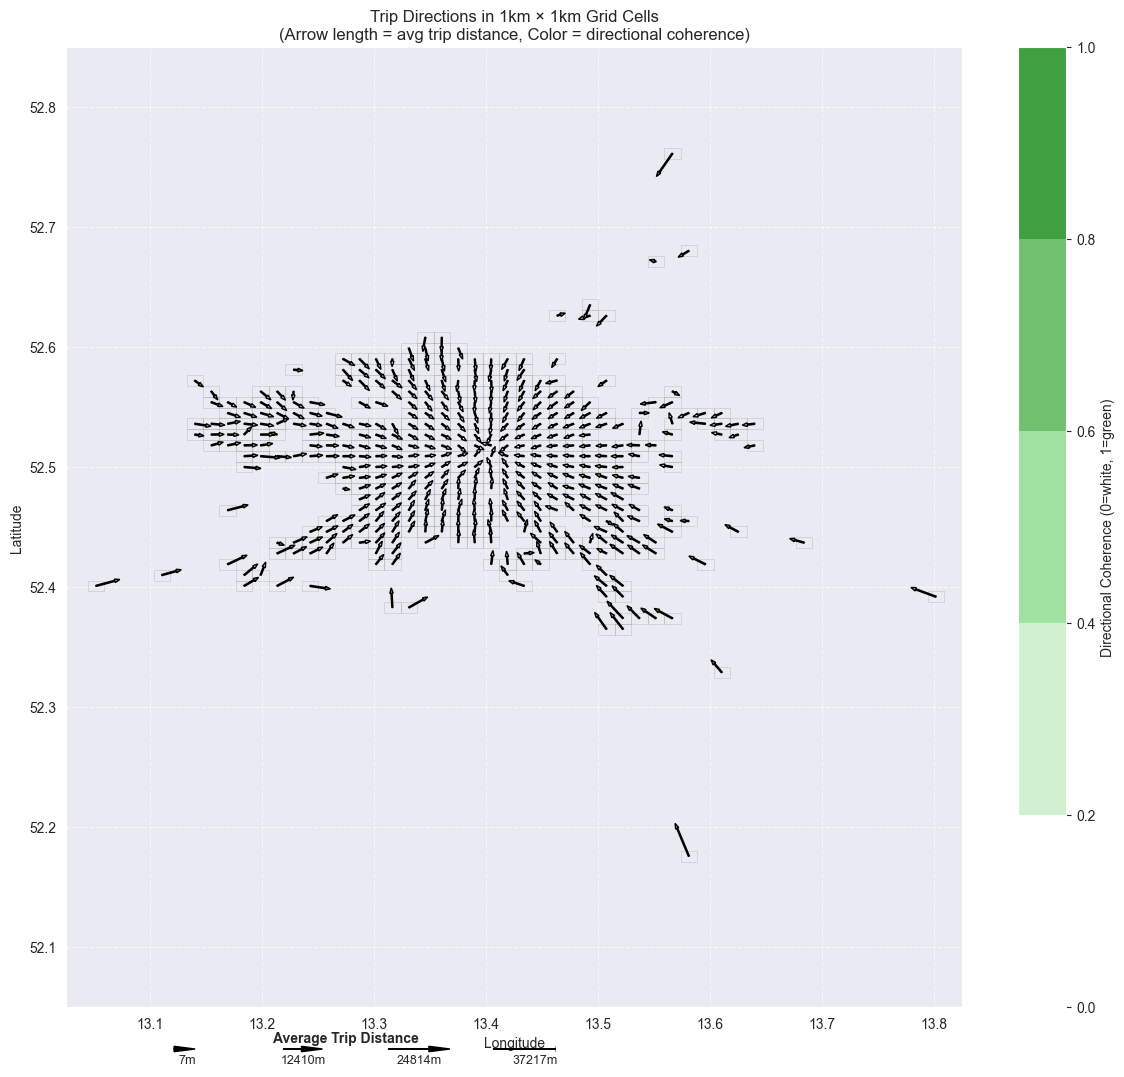

In [38]:
white_to_green = ListedColormap(['white', '#d0f0d0', '#a0e0a0', '#70c070', '#40a040'])

# Create the visualization
plt.figure(figsize=(14, 12))

# Plot grid cells as rectangles
rects = []
for _, row in grid_df.iterrows():
    grid_lat, grid_lon = row['grid_id'].split('_')
    min_lon = 13 + int(grid_lon) * GRID_SIZE / LON_METERS
    min_lat = 52 + int(grid_lat) * GRID_SIZE / LAT_METERS
    width = GRID_SIZE / LON_METERS
    height = GRID_SIZE / LAT_METERS
    
    rect = patches.Rectangle((min_lon, min_lat), width, height, 
                            linewidth=0.5, edgecolor='gray', facecolor='none', alpha=0.3)
    rects.append(rect)

# Add grid cells to plot
pc = PatchCollection(rects, match_original=True)
plt.gca().add_collection(pc)

# Find min and max trip counts for color normalization
min_count = grid_df['count'].min()
max_count = grid_df['count'].max()
count_norm = plt.Normalize(min_count, max_count)

# Find min and max distances for arrow length scaling
min_dist = grid_df['avg_distance'].min()
max_dist = grid_df['avg_distance'].max()

# Base arrow scale - will be multiplied by normalized distance
arrow_base_scale = 0.03
arrow_width = 0.0015

# Plot arrows for each grid cell
for _, row in grid_df.iterrows():
    direction_rad = radians(row['avg_direction'])
    
    # Scale arrow length by average trip distance
    # Normalize distance to 0-1 range and scale it
    norm_distance = (row['avg_distance'] - min_dist) / (max_dist - min_dist) if max_dist > min_dist else 0.5
    arrow_length = arrow_base_scale * (0.2 + 0.8 * norm_distance)  # Ensure minimum visibility
    
    dx = arrow_length * sin(direction_rad)
    dy = arrow_length * cos(direction_rad)
    
    # Get color based on trip count
    color_idx = int(row['coherence'] * 4)
    arrow_color = white_to_green(color_idx)
    
    # Draw the arrow
    plt.arrow(row['center_lon'], row['center_lat'], 
              dx, dy, 
              head_width=arrow_width * 2, 
              head_length=arrow_width * 3, 
              fc=arrow_color, ec='black', 
              length_includes_head=True,
              zorder=10,
              alpha=1.0)

# Set plot limits to the filtered area
plt.xlim(13.025, 13.825)
plt.ylim(52.05, 52.85)

# Add a colorbar for trip count
sm = plt.cm.ScalarMappable(cmap=white_to_green, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Directional Coherence (0=white, 1=green)')

# Add labels and title
plt.title('Trip Directions in 1km × 1km Grid Cells\n(Arrow length = avg trip distance, Color = directional coherence)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a legend for arrow length
# Create dummy arrows for the legend
distance_markers = np.linspace(min_dist, max_dist, 4)
distance_markers = np.round(distance_markers).astype(int)
legend_elements = []

# Create a separate axis for the distance legend
legend_ax = plt.axes([0.15, 0.05, 0.3, 0.03], frameon=False)  # [left, bottom, width, height]
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_axis_off()

# Draw arrows of different lengths
for i, dist in enumerate(distance_markers):
    norm_dist = (dist - min_dist) / (max_dist - min_dist) if max_dist > min_dist else 0.5
    arrow_len = 0.2 * (0.2 + 0.8 * norm_dist)
    x_pos = 0.1 + i * 0.25
    legend_ax.arrow(x_pos, 0.5, arrow_len, 0, 
                   head_width=0.15, head_length=0.05, 
                   fc='black', ec='black', 
                   length_includes_head=True)
    legend_ax.text(x_pos + arrow_len/2, 0.2, f"{dist}m", 
                  ha='center', va='center', fontsize=9)

legend_ax.text(0.5, 0.8, "Average Trip Distance", ha='center', va='center', fontsize=10, fontweight='bold')

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
plt.show()

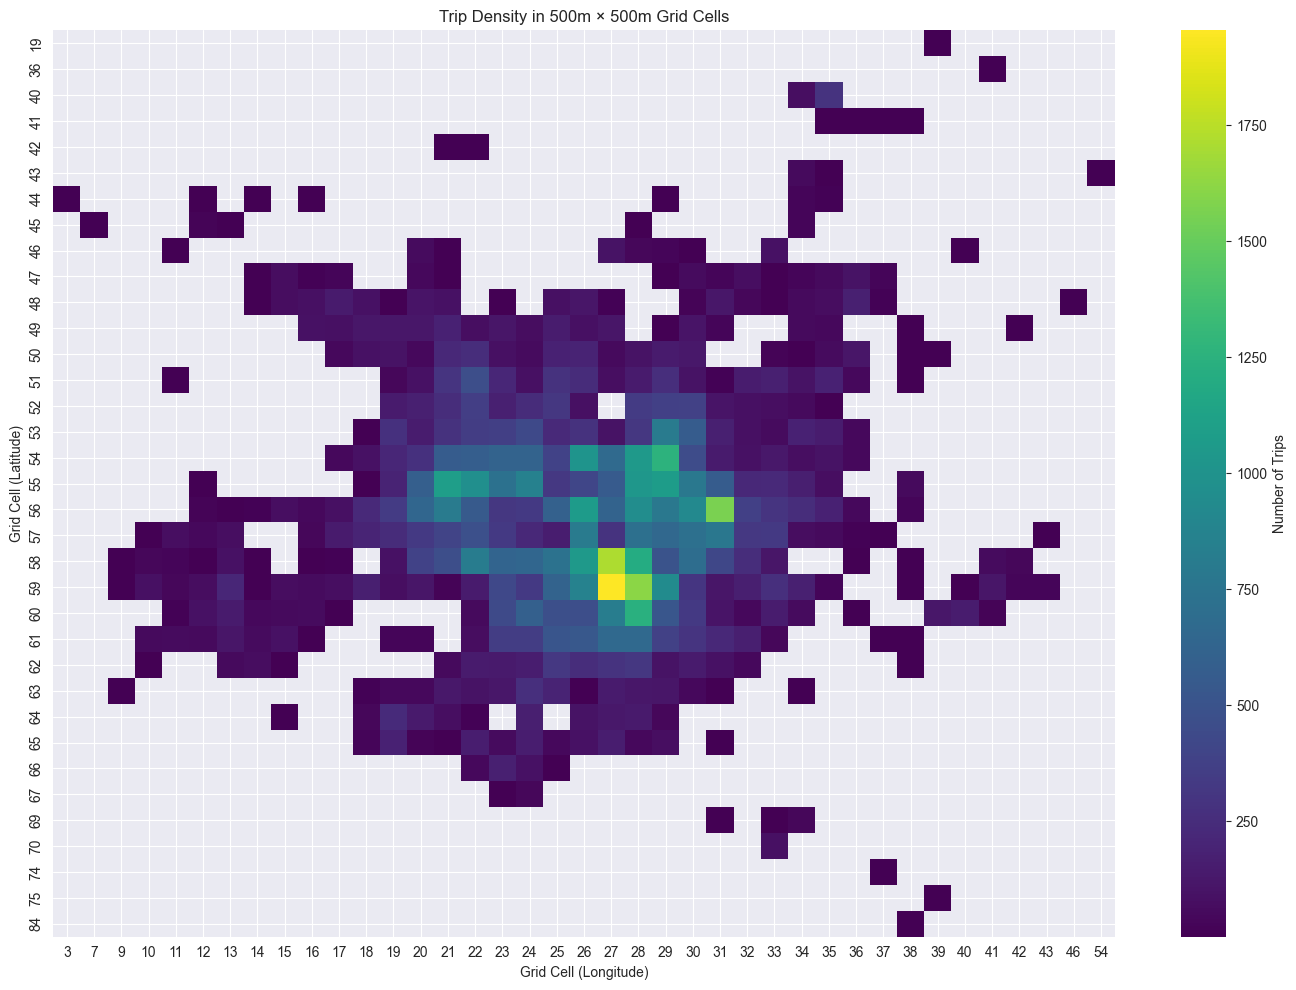

In [55]:
plt.figure(figsize=(14, 10))

heatmap_data = filtered.groupby(['grid_lat', 'grid_lon']).size().reset_index(name='count')
pivot_data = heatmap_data.pivot(index='grid_lat', columns='grid_lon', values='count')

ax = sns.heatmap(pivot_data, cmap='viridis', cbar_kws={'label': 'Number of Trips'})

ax.set_title('Trip Density in 500m × 500m Grid Cells')
ax.set_xlabel('Grid Cell (Longitude)')
ax.set_ylabel('Grid Cell (Latitude)')

plt.tight_layout()
plt.show()